2.1 模型训练小流程

In [3]:
import torch
import numpy as np
from torch.utils import data
import d2l
from d2l import torch as d2l
# torch.ones(2)#矢量级运算提高速度

true_w = torch.tensor([2.0,-3.4])
true_b = torch.tensor(4.2)
features,labels = d2l.synthetic_data(true_w,true_b,1000)

In [4]:
def load_array(data_arrays,batch_size,is_train=True):
    """构造一个PyTorch数据迭代器"""
    dataset=data.TensorDataset(*data_arrays)
    return data.DataLoader(dataset,batch_size,shuffle=is_train)

batch_size=10#data_iter = load_array((features, labels), batch_size)
data_iter = load_array((features, labels), batch_size)
X,y = next(iter(data_iter))
X,y

(tensor([[ 2.5481, -1.6068],
         [ 0.5801,  1.4975],
         [ 0.6322, -0.7825],
         [ 0.7315, -0.5147],
         [ 0.1500, -0.7598],
         [-1.0968,  0.9961],
         [-2.0393, -0.7963],
         [-0.8773,  0.3800],
         [ 1.8663, -0.5235],
         [ 0.8819, -0.2873]]),
 tensor([[14.7592],
         [ 0.2575],
         [ 8.1334],
         [ 7.4180],
         [ 7.1001],
         [-1.3650],
         [ 2.8375],
         [ 1.1577],
         [ 9.7197],
         [ 6.9453]]))

In [5]:
from torch import nn
net = nn.Sequential(nn.Linear(2,1))#定义模型
net[0].weight.data.normal_(0,0.01)#定义模型参数
net[0].bias.data.fill_(0)


tensor([0.])

In [6]:
loss = nn.MSELoss()#定义损失函数
trainer = torch.optim.SGD(net.parameters(),lr = 0.03)#定义优化算法
num_epochs = 3
for epoch in range(num_epochs):
    for X,y in data_iter:
        l = loss(net(X),y.reshape(net(X).shape))
        trainer.zero_grad()
        l.backward()
        trainer.step()
    l = loss(net(features),labels)
    print(f"epoch{epoch+1},loss  {l:f}")#模型训练

epoch1,loss  0.000221
epoch2,loss  0.000100
epoch3,loss  0.000099


In [7]:
w = net[0].weight.data
print("w的估计误差：",true_w - w.reshape(true_w.shape))
b = net[0].bias.data
print("b的估计误差：",true_b - b)
w,b

w的估计误差： tensor([-3.0875e-04,  7.3195e-05])
b的估计误差： tensor([-0.0001])


(tensor([[ 2.0003, -3.4001]]), tensor([4.2001]))

2.2 Fashion MNIST服装分类数据集

In [8]:
import torchvision
from torch.utils import data
from torchvision import transforms

d2l.use_svg_display()

In [9]:
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(root="../data",train=True,transform=trans,download=True)
mnist_test = torchvision.datasets.FashionMNIST(root="../data",train=False,transform=trans,download=True)
len(mnist_train),len(mnist_test)

(60000, 10000)

In [10]:
image,label =mnist_train[0]
image.shape,label
mnist_train[23][1]

8

In [11]:
def get_fashion_mnist_labels(labels):
    """返回Fashion-MNIST数据集的文本标签"""
    text_labels = ['t_shirt','trouser','pullover','dress','coat','sandal','shirt','sneaker','bag','ankle boot']
    return [text_labels[int(i)] for i in labels]

def show_images(imgs,num_rows,num_cols,titles=None,scale=1.5):
    """绘制图像列表"""
    figsize = (num_cols*scale,num_rows*scale)
    _,axes = d2l.plt.subplots(num_rows,num_cols,figsize=figsize)
    axes = axes.flatten()
    for i,(ax,img) in enumerate(zip(axes,imgs)):
        if torch.is_tensor(img):
            # 图片张量
            ax.imshow(img.numpy())
        else:
            # PIL图片
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't_shirt'}>,
       <Axes: title={'center': 't_shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't_shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>], dtype=object)

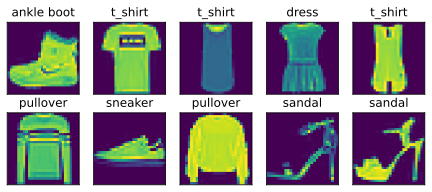

In [12]:
X,y = next(iter(data.DataLoader(mnist_train,batch_size=18)))
show_images(X.reshape(18,28,28),2,5,titles=get_fashion_mnist_labels(y))

In [13]:
batch_size=256

def get_dataloader_workers():
    """使用4个进程来读取数据"""
    return 4

train_iter = data.DataLoader(mnist_train,batch_size,shuffle=True,num_workers=get_dataloader_workers())

In [14]:
timer = d2l.Timer()
for X,y in train_iter:
    continue
print(f"{timer.stop():.2f} sec")

9.23 sec


In [15]:
def load_data_fashion_mnist(batch_size,resize=None):
    """下载Fashion-MNIST数据集，然后将其加载到内存中"""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0,transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data",train=True,transform=trans,download=True
    )
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data",train=False,transform=trans,download=True
    )
    return (data.DataLoader(mnist_train,batch_size,shuffle=True,
                            num_workers=get_dataloader_workers()),
            data.DataLoader(mnist_test,batch_size,shuffle=True,
                            num_workers=get_dataloader_workers()))

train_iter,test_iter = load_data_fashion_mnist(32,resize=64)
for X,y in train_iter:
    print(X.shape,X.dtype,y.shape,y.dtype)
    break

torch.Size([32, 1, 64, 64]) torch.float32 torch.Size([32]) torch.int64


2.3 softmax实现---最简单单层神经网络

In [16]:
batch_size = 256
train_iter,test_iter = load_data_fashion_mnist(batch_size)
net = nn.Sequential(nn.Flatten(),nn.Linear(784,10))

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight,std=0.01)
        nn.init.zeros_(m.bias)

net.apply(init_weights)

loss = nn.CrossEntropyLoss(reduction='none')
trainer = torch.optim.SGD(net.parameters(),lr=0.1)


In [17]:
def train_epoch(net,train_iter,loss,trainer):
    "训练模型一个迭代周期"
    if isinstance(net,nn.Module):
        net.train()
    metric = d2l.Accumulator(3)
    for X,y in train_iter:
        y_hat = net(X)
        l = loss(y_hat,y)
        trainer.zero_grad()
        l.mean().backward()
        trainer.step()
        metric.add(float(l.sum()),d2l.accuracy(y_hat,y),y.numel())
    return metric[0]/metric[2],metric[1]/metric[2]


In [18]:
num_epochs = 10
for epoch in range(num_epochs):
    train_loss,train_acc = train_epoch(net,train_iter,loss,trainer)
    print(f'第{epoch+1}轮，训练损失{train_loss:.3f},训练精度{train_acc:.3f}')
    break
    

C:\Users\hmm\AppData\Local\Temp\ipykernel_27408\4209798338.py:12: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  metric.add(float(l.sum()),d2l.accuracy(y_hat,y),y.numel())


第1轮，训练损失0.788,训练精度0.749
